# Data-Driven Operator Learning for Transient Nonlinear Heat Conduction

*A Fourier Neural Operator (FNO) trained on finite-element data to predict the time evolution of temperature in a heterogeneous, nonlinear rod.*

---

## 1. Problem statement

We study transient heat conduction in a 1-D rod on the domain $x \in [0,1]$. The temperature field $T(x,t)$ obeys the nonlinear parabolic equation

$$\rho c_p \,\frac{\partial T}{\partial t} = \frac{\partial}{\partial x}\left( k(x,T)\,\frac{\partial T}{\partial x} \right),$$

with a conductivity that is **both spatially heterogeneous and temperature-dependent**:

$$k(x,T) = \alpha(x)\,\bigl(0.5 + T^{2}\bigr).$$

The $T^{2}$ term makes the problem nonlinear (hotter regions conduct more heat), while $\alpha(x)$ encodes the material. Dirichlet boundary conditions $T(0,t)=1$ and $T(1,t)=0$ are held fixed.

**Goal.** Rather than re-solving this PDE from scratch for every new material $\alpha(x)$ and initial state $T_0(x)$, we *learn the solution operator* — the map that advances the temperature field by one time step — and apply it repeatedly to roll a full trajectory forward in time.

## 2. Reference solver: implicit finite elements

Ground-truth trajectories come from a standard finite-element method (FEM). The domain is split into linear elements; the conduction (stiffness $K$) and heat-capacity (mass $M$) matrices are assembled, and time is advanced with the **backward-Euler** scheme

$$\bigl(M(T_{n+1}) + \Delta t\,K(T_{n+1})\bigr)\,T_{n+1} = M(T_n)\,T_{n}.$$

Because $k(x,T)$ depends on the *unknown* $T_{n+1}$, this is genuinely implicit: each step is solved with a few Newton-Raphson iterations (exact Jacobian, `jax.jacfwd`) rather than a single linear solve. The solver, the random-field sampler and the out-of-distribution scenarios all come from `fem_ground_truth.py`, the one FEM module shared by every transient chapter (see the note below).

<div align="center">

<br><em style="color:#475569;font-size:0.9em">Figure 1. From random samples to a supervised dataset: FEM produces reference trajectories, sliced into one-step input/target pairs.</em>
</div>

**Shared ground truth.** Every transient chapter in this book reads its initial fields, materials and reference trajectories from one module, `fem_ground_truth.py`. A fixed pool of 1000 $(T_0,\alpha)$ fields (a Fourier-series / Gaussian-random-process / constant mixture, after Yamazaki et al. 2025, Sect. 3.3) is solved **once** with fully-implicit backward-Euler FEM (Newton–Raphson, exact Jacobian) on a fine mesh ($N=256$, $\Delta t=0.001$, $t\in[0,0.4]$). Each chapter then derives its own $(N,\Delta t)$ from that one solve by spatial interpolation and exact time sub-sampling, without re-solving. So every model is graded against the same converged answer, and not against a coarse solve that carries its own discretization error. The 1000 samples are split 800 / 100 / 100 (train / validation for early stopping / held-out test) identically in every chapter. The out-of-distribution scenarios come from the same module (50 unseen shapes solved once at $N=512$). Full details: [The Benchmark Problem](benchmark_problem.ipynb).

## 3. The neural operator: Fourier Neural Operator (FNO)

A conventional network learns a fixed vector-to-vector map. A **neural operator** instead learns a map between *functions*, which is what lets it generalize across different material and initial fields. The FNO does this with **spectral convolutions**: it moves each layer's signal to the frequency domain, keeps only the lowest $k$ Fourier modes (a global, resolution-independent filter), applies learnable complex weights $R$, and transforms back — in parallel with a local linear skip connection $W$:

$$\text{layer}(v) = \sigma\Bigl( \mathcal{F}^{-1}\bigl(R\cdot\mathcal{F}(v)\bigr) + W v \Bigr),\qquad \sigma=\text{GELU}.$$

The network reads three input channels — current temperature $T_n$, material $\alpha(x)$, and the coordinate $x$ — and predicts the **time-derivative** $\dot T$, integrated forward with one explicit-Euler step of size $\Delta t$. A boundary mask that vanishes at both ends guarantees the fixed boundary values are never disturbed:

$$T_{n+1} = T_n + \Delta t\,\text{mask}(x)\cdot \dot T,\qquad \text{mask}(x)=\sin(\pi x).$$

<div align="center">

<br><em style="color:#475569;font-size:0.9em">Figure 2. The FNO advances the field one step (lift, spectral layers, project, masked residual update), then is applied autoregressively.</em>
</div>

## 4. Training objective

The operator is trained by supervised regression: over all one-step pairs, minimize the mean-squared error between the FNO prediction and the FEM target,

$$\mathcal{L} = \bigl\langle \lVert \text{FNO}(T_n,\alpha,x) - T_{n+1}^{\text{FEM}} \rVert^2 \bigr\rangle .$$

Optimization uses **AdamW** with a cosine-decayed learning rate and weight decay. Rather than a fixed epoch count, training uses **early stopping**: a held-out validation set decides when to stop and which checkpoint to keep (Section 5). Section 9 checks whether in-distribution validation is a safe selection criterion by also tracking out-of-distribution error across training.

### Model configuration

| Setting | Value | Meaning |
| :--- | :--- | :--- |
| Grid nodes | 64 | Spatial resolution of the rod |
| Spectral layers | 4 | Depth of the operator |
| Fourier modes kept | 4 | Low-frequency modes retained per layer (matched across all transient chapters) |
| Channel width | 64 | Hidden dimension |
| Time steps / trajectory | 20 | Rollout horizon |
| Samples | 1000 (800 train, 100 validation, 100 test) | Distinct $(\alpha,\,T_0)$ trajectories |
| Epoch budget | ≤ 20000, early-stopped | Same budget as the weighted-residual and PITI chapters |
| Optimizer | AdamW, LR = 1e-3 (cosine decay), weight-decay 1e-4 | — |
| Activation | GELU | Nonlinearity |

*(These values are read directly from `config.py` below.)*

In [1]:
%%writefile config.py
import jax.numpy as jnp

# Resolution, split and dt are shared with the weighted-residual and PITI chapters.
N_NODES = 64
N_GRID = N_NODES - 1
WIDTH = 64
MODES = 4
BATCH_SIZE = 32
N_SAMPLES = 1000
TRAIN_SAMPLES = 800
VAL_SAMPLES = 100                                   # held out from training, used for early stopping
ROLLOUT_TEST_START = TRAIN_SAMPLES + VAL_SAMPLES    # last 100: never seen by training or early stopping
MAX_STEPS = 20
DT = 0.02
RHO_CP = 5.0
GRID = jnp.linspace(0, 1, N_NODES)

# FEM ground truth: fem_ground_truth.py's cached fine reference (N=256, dt=0.001, 400 steps,
# fully-implicit Newton-Raphson), interpolated down to (N_NODES, DT) -- never re-solved here.
POOL_PATH = "checkpoints/field_pool.npz"
REFERENCE_PATH = "checkpoints/fine_reference.npz"
OOD_REFERENCE_PATH = "checkpoints/ood_fine_reference.pkl"
REF_DT, REF_STEPS = 0.001, 400

# Early stopping (no fixed epoch count): train up to MAX_EPOCHS, stopping sooner if
# held-out validation MSE stalls/worsens for PATIENCE consecutive checks.
MAX_EPOCHS = 20000      # same budget as the weighted-residual and PITI chapters
# Optional cap on CHECKPOINT SELECTION (training still runs to MAX_EPOCHS). An earlier
# version of this chapter capped it at 12000 because OOD error appeared to rise under long
# training; on the shared FEM reference Section 9 shows OOD error keeps FALLING instead,
# so no cap is applied.
DATA_MAX_EPOCHS = MAX_EPOCHS
CHECK_EVERY = 200
PATIENCE = 15


Overwriting config.py


In [2]:
# The FEM solver, the in-distribution (T0, alpha) sampler and the out-of-distribution
# scenarios are not defined in this chapter: they live in fem_ground_truth.py, the one
# FEM module every transient chapter imports, so the data-driven, weighted-residual and
# PITI operators are all trained and graded against the same fully-implicit
# Newton-Raphson reference.
import fem_ground_truth

In [3]:
%%writefile model.py
import jax
import jax.numpy as jnp
from config import WIDTH, MODES, DT

def spectral_layer(x, w_spec, w_skip):
    n = x.shape[0]
    x_ft = jnp.fft.rfft(x, axis=0)
    out_ft = jnp.zeros_like(x_ft, dtype=jnp.complex64).at[:MODES].set(
        jnp.einsum('mi, mij -> mj', x_ft[:MODES], w_spec))
    return jax.nn.gelu(jnp.fft.irfft(out_ft, n=n, axis=0) + jnp.dot(x, w_skip))

def fno_model(params, x_norm, T_curr):
    # Predicts the time-derivative T-dot, not the raw increment; one explicit-Euler
    # step of size DT turns that rate into the next state: T_next = T_curr + DT*Tdot.
    x = jax.nn.gelu(jnp.dot(x_norm, params[0]) + params[1])
    for i in range(2, 10, 2):
        x = spectral_layer(x, params[i], params[i+1])
    x = jax.nn.gelu(jnp.dot(x, params[10]) + params[11])
    T_dot = (jnp.dot(x, params[12]) + params[13]).squeeze()
    # Resolution-generic: the mask is sized from the input, so the same weights run on
    # finer grids (super-resolution OOD test, Section 8).
    mask = jnp.sin(jnp.pi * jnp.linspace(0, 1, T_curr.shape[0]))
    return T_curr + DT * (T_dot * mask)

def init_params(key):
    keys = jax.random.split(key, 12)
    def norm_init(k, s): return jax.random.normal(k, s) * jnp.sqrt(1.0 / s[-1])
    p = [norm_init(keys[0], (3, WIDTH)), jnp.zeros(WIDTH)]
    for i in range(4):
        p.append(jax.random.normal(keys[i+1], (MODES, WIDTH, WIDTH), dtype=jnp.complex64) * 0.02)
        p.append(norm_init(keys[i+5], (WIDTH, WIDTH)))
    p.extend([norm_init(keys[10], (WIDTH, WIDTH)), jnp.zeros(WIDTH),
              norm_init(keys[11], (WIDTH, 1)), jnp.zeros(1)])
    return p


Overwriting model.py


In [4]:
%%writefile plotting.py
import matplotlib.pyplot as plt
import numpy as np
from config import GRID, MAX_STEPS

def plot_results(epochs_recorded, train_loss_history, val_loss_history, true_traj, fno_traj, abs_error, T0_test):
    plt.rcParams.update({'font.size': 11})
    
    # Create a figure with a 2-row, 1-column grid layout
    fig = plt.figure(figsize=(10, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.1])

    # ==========================================
    # ROW 1: Training & Validation Convergence 
    # ==========================================
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(epochs_recorded, train_loss_history, color='#2c3e50', lw=2, label='Train Loss (Batch)')
    ax0.plot(epochs_recorded, val_loss_history, color='#e74c3c', lw=2, ls='--', label='Validation Loss (Unseen)')
    ax0.set_yscale('log')
    ax0.set_title("Training & Validation Convergence", fontweight='bold', fontsize=14, pad=10)
    ax0.set_xlabel("Actual Epochs")
    ax0.set_ylabel("Loss (MSE)")
    ax0.grid(True, which="both", ls="-", alpha=0.2)
    ax0.legend(loc='upper right')

    # Time and Grid extensions for 2D plotting
    time_steps = np.arange(MAX_STEPS)
    T, X = np.meshgrid(time_steps, GRID)

    # ==========================================
    # ROW 2: Space-Time Rollout Trajectories
    # ==========================================
    # Absolute Error Only
    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.imshow(abs_error.T, aspect='auto', origin='lower', cmap='inferno',
                     extent=[0, MAX_STEPS-1, 0, 1])
    ax3.set_title("Absolute Prediction Error", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Grid (x)")
    fig.colorbar(im3, ax=ax3, label="Error Magnitude")

    plt.tight_layout()
    plt.show()

Overwriting plotting.py


## 5. Train the operator

The cell below loads the shared FEM reference, trains the FNO, and shows the convergence curve together with a space-time map of the prediction error for one held-out trajectory. A validation curve that tracks the training curve indicates the operator is learning the physics rather than memorizing it.

Loading the shared FEM reference (fully-implicit Newton-Raphson, fem_ground_truth.py)...


Training for up to 20000 epochs (checkpoint capped at 20000), with early stopping...


Epoch     0 | Train MSE: 4.846697e-04 | Val MSE: 3.866261e-04  * best


Epoch  1000 | Train MSE: 7.164445e-05 | Val MSE: 1.329340e-04  * best


Epoch  2000 | Train MSE: 1.143070e-04 | Val MSE: 7.302991e-05  * best


Epoch  3000 | Train MSE: 4.037899e-05 | Val MSE: 3.483523e-05


Epoch  4000 | Train MSE: 5.182976e-05 | Val MSE: 3.191409e-05


Epoch  5000 | Train MSE: 2.354912e-05 | Val MSE: 2.490696e-05


Epoch  6000 | Train MSE: 1.530559e-05 | Val MSE: 1.956267e-05  * best


Epoch  7000 | Train MSE: 1.086789e-05 | Val MSE: 1.940723e-05


Epoch  8000 | Train MSE: 2.259794e-05 | Val MSE: 1.921687e-05


Epoch  9000 | Train MSE: 6.496167e-06 | Val MSE: 1.706677e-05  * best


Epoch 10000 | Train MSE: 9.074924e-06 | Val MSE: 1.387513e-05  * best


Epoch 11000 | Train MSE: 1.088089e-05 | Val MSE: 1.293217e-05


Epoch 12000 | Train MSE: 1.312782e-05 | Val MSE: 1.220917e-05


Epoch 13000 | Train MSE: 1.023904e-05 | Val MSE: 1.163165e-05


Epoch 14000 | Train MSE: 1.401663e-05 | Val MSE: 1.124254e-05


Epoch 15000 | Train MSE: 9.621155e-06 | Val MSE: 1.071894e-05  * best


Epoch 16000 | Train MSE: 1.088932e-05 | Val MSE: 1.058842e-05  * best


Epoch 17000 | Train MSE: 1.679378e-05 | Val MSE: 1.032626e-05


Epoch 18000 | Train MSE: 1.157511e-05 | Val MSE: 1.014193e-05  * best


Epoch 19000 | Train MSE: 2.360783e-05 | Val MSE: 1.014715e-05


Hit max_epochs=20000 without early stopping (best val 1.001e-05 @ epoch 19800)
Saved best-checkpoint (epoch<=DATA_MAX_EPOCHS) params to checkpoints/params_data_driven.npz


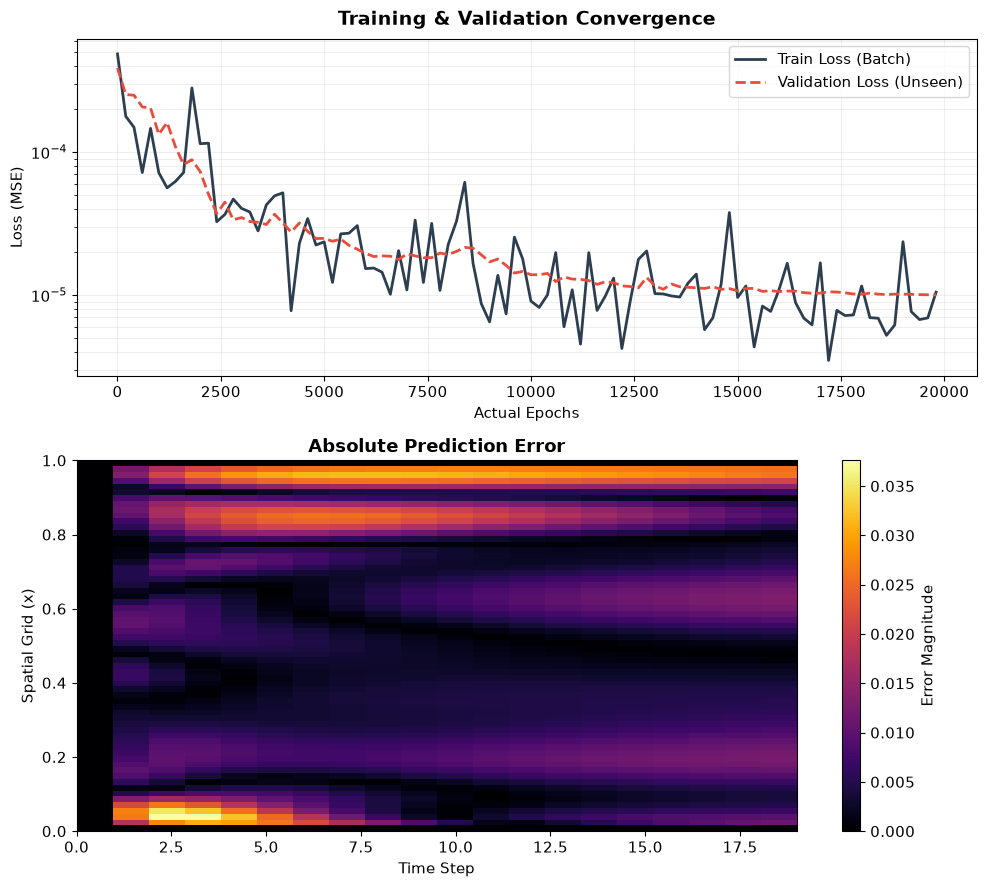

In [5]:
%load_ext autoreload
%autoreload 2

import os
import jax
import jax.numpy as jnp
import numpy as np
import optax
from config import *
import model
import plotting

from fem_ground_truth import get_reference_trajectory, derive_dataset

# 1. LOAD THE SHARED FEM REFERENCE -- read from the cache (no solving), interpolated
#    down to N_NODES and sub-sampled to DT by exact stride.
print("Loading the shared FEM reference (fully-implicit Newton-Raphson, fem_ground_truth.py)...")
reference_data = get_reference_trajectory(REFERENCE_PATH, POOL_PATH, dt_ref=REF_DT, steps_ref=REF_STEPS)
fem_dataset = derive_dataset(reference_data, n_nodes_target=N_NODES, dt_target=DT)
true_traj_all = jnp.asarray(fem_dataset["trajectory"])[:, :MAX_STEPS]   # (N_SAMPLES, MAX_STEPS, N_NODES), t = 0..0.38
all_T0 = true_traj_all[:, 0]
all_Alpha = jnp.asarray(fem_dataset["alpha"])
all_X_T, all_Y_T = true_traj_all[:, :-1], true_traj_all[:, 1:]          # one-step (input, target) pairs

# 2. DATA PREPARATION (Train & Validation Splits)
grid_expanded = jnp.tile(GRID, (N_SAMPLES, MAX_STEPS-1, 1))
X_raw = jnp.stack([all_X_T, jnp.tile(all_Alpha[:, None, :], (1, MAX_STEPS-1, 1)), grid_expanded], axis=-1)
Y_raw = all_Y_T[..., None]

X_train_flat = X_raw[:TRAIN_SAMPLES].reshape(-1, N_NODES, 3)
Y_train_flat = Y_raw[:TRAIN_SAMPLES].reshape(-1, N_NODES, 1)

# Validation set -- used for early stopping (best-checkpoint selection), not just monitoring.
X_val_flat = X_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].reshape(-1, N_NODES, 3)
Y_val_flat = Y_raw[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].reshape(-1, N_NODES, 1)

x_mean, x_std = X_train_flat.mean(axis=(0, 1)), X_train_flat.std(axis=(0, 1)) + 1e-7
X_train_norm = (X_train_flat - x_mean) / x_std
X_val_norm = (X_val_flat - x_mean) / x_std

# 3. TRAINING: ONE run, up to MAX_EPOCHS -- with an important fix. The
# learning-rate schedule always decays over the FULL MAX_EPOCHS horizon
# (fixed, generous), never over just DATA_MAX_EPOCHS. We found that coupling
# the LR schedule's length to a lower epoch cap makes the optimizer anneal
# much faster and settle into a sharper, more OOD-fragile solution by that
# cap -- a dedicated short-schedule run behaves worse than a long-schedule
# run's snapshot at the same nominal epoch, even though both saw identical
# data up to that point. Only the CHECKPOINT SELECTION is capped at
# DATA_MAX_EPOCHS; training itself (and snapshotting, for the diagnostic in
# Section 9 below) continues under the same fixed schedule all the way to
# MAX_EPOCHS. This also means Section 9 no longer needs a second, separate
# training run -- the snapshots collected here serve both purposes.
def make_opt(max_epochs):
    sched = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=max_epochs, alpha=1e-2)
    return optax.adamw(learning_rate=sched, weight_decay=1e-4)

@jax.jit
def val_mse(p):
    T_curr = X_val_flat[:, :, 0]
    preds = jax.vmap(model.fno_model, (None, 0, 0))(p, X_val_norm, T_curr)
    return jnp.mean((preds - Y_val_flat.squeeze())**2)

def train_early_stop(max_epochs, snapshot_every=None, cap_epochs=None):
    # cap_epochs: if given, the checkpoint returned is the best-validation
    # checkpoint restricted to epoch<=cap_epochs (used for everything else in
    # this chapter), while the loop still runs -- and snapshots -- all the
    # way to max_epochs. Leave None for plain early stopping with no cap.
    if cap_epochs is None: cap_epochs = max_epochs
    params = model.init_params(jax.random.PRNGKey(123))
    opt = make_opt(max_epochs); opt_state = opt.init(params)

    @jax.jit
    def train_step(p, opt_s, b_X_norm, b_X_raw, b_Y):
        T_curr_batch = b_X_raw[:, :, 0]
        loss_fn = lambda p: jnp.mean((jax.vmap(model.fno_model, (None, 0, 0))(p, b_X_norm, T_curr_batch) - b_Y.squeeze())**2)
        l, g = jax.value_and_grad(loss_fn)(p)
        u, opt_s = opt.update(g, opt_s, p)
        return optax.apply_updates(p, u), opt_s, l

    loss_history, val_history, epochs_recorded = [], [], []
    best_val, best_params, best_epoch, stall = jnp.inf, params, 0, 0
    capped_val, capped_params, capped_epoch = jnp.inf, params, 0
    snapshots = []
    for i in range(max_epochs):
        idx = jax.random.randint(jax.random.PRNGKey(i), (BATCH_SIZE,), 0, X_train_flat.shape[0])
        params, opt_state, loss = train_step(params, opt_state, X_train_norm[idx], X_train_flat[idx], Y_train_flat[idx])
        if snapshot_every is not None and i % snapshot_every == 0:
            snapshots.append((i, params))
        if i % CHECK_EVERY == 0:
            v = float(val_mse(params))
            loss_history.append(float(loss)); val_history.append(v); epochs_recorded.append(i)
            improved = v < best_val
            if i % 1000 == 0:
                print(f"Epoch {i:5d} | Train MSE: {loss:.6e} | Val MSE: {v:.6e}" + ("  * best" if improved else ""))
            if improved:
                best_val, best_params, best_epoch, stall = v, params, i, 0
            else:
                stall += 1
                if stall >= PATIENCE:
                    print(f"Early-stopped at epoch {i} (best val {best_val:.3e} @ epoch {best_epoch})")
                    break
            if i <= cap_epochs and v < capped_val:
                capped_val, capped_params, capped_epoch = v, params, i
    else:
        print(f"Hit max_epochs={max_epochs} without early stopping (best val {best_val:.3e} @ epoch {best_epoch})")
    if cap_epochs < max_epochs:
        print(f"Checkpoint used downstream: best val {capped_val:.3e} @ epoch {capped_epoch} (restricted to epoch<={cap_epochs})")
        best_params = capped_params
    return (best_params, loss_history, val_history, epochs_recorded, snapshots)

print(f"Training for up to {MAX_EPOCHS} epochs (checkpoint capped at {DATA_MAX_EPOCHS}), with early stopping...")
params, loss_history, val_history, epochs_recorded, snapshots = train_early_stop(
    MAX_EPOCHS, snapshot_every=1000, cap_epochs=DATA_MAX_EPOCHS)

os.makedirs("checkpoints", exist_ok=True)
np.savez("checkpoints/params_data_driven.npz", *[np.asarray(pi) for pi in params])
print("Saved best-checkpoint (epoch<=DATA_MAX_EPOCHS) params to checkpoints/params_data_driven.npz")

# 4. ROLLOUT EVALUATION (On a single unseen target test profile)
test_idx = ROLLOUT_TEST_START + 5
T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]

def rollout_fno(p, T_init, alpha_prof, steps):
    def step(T_curr, _):
        x_norm = (jnp.stack([T_curr, alpha_prof, GRID], axis=-1) - x_mean) / x_std
        T_next = model.fno_model(p, x_norm, T_curr)
        return T_next, T_next
    return jax.lax.scan(step, T_init, None, length=steps)[1]

true_traj = true_traj_all[test_idx]
fno_traj = jnp.vstack([T0_test, rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)])
abs_error = jnp.abs(true_traj - fno_traj)

# 5. VISUALIZE
plotting.plot_results(epochs_recorded, loss_history, val_history, true_traj, fno_traj, abs_error, T0_test)


## 6. Error growth over the rollout

Rolling a learned operator forward feeds its own output back as input, so small per-step errors can accumulate. These box plots show the distribution of spatial error at each time step, for training and unseen test trajectories separately. Low, flat boxes on the test set mean the model stays accurate deep into the rollout.

Computing full rollout errors for all samples...


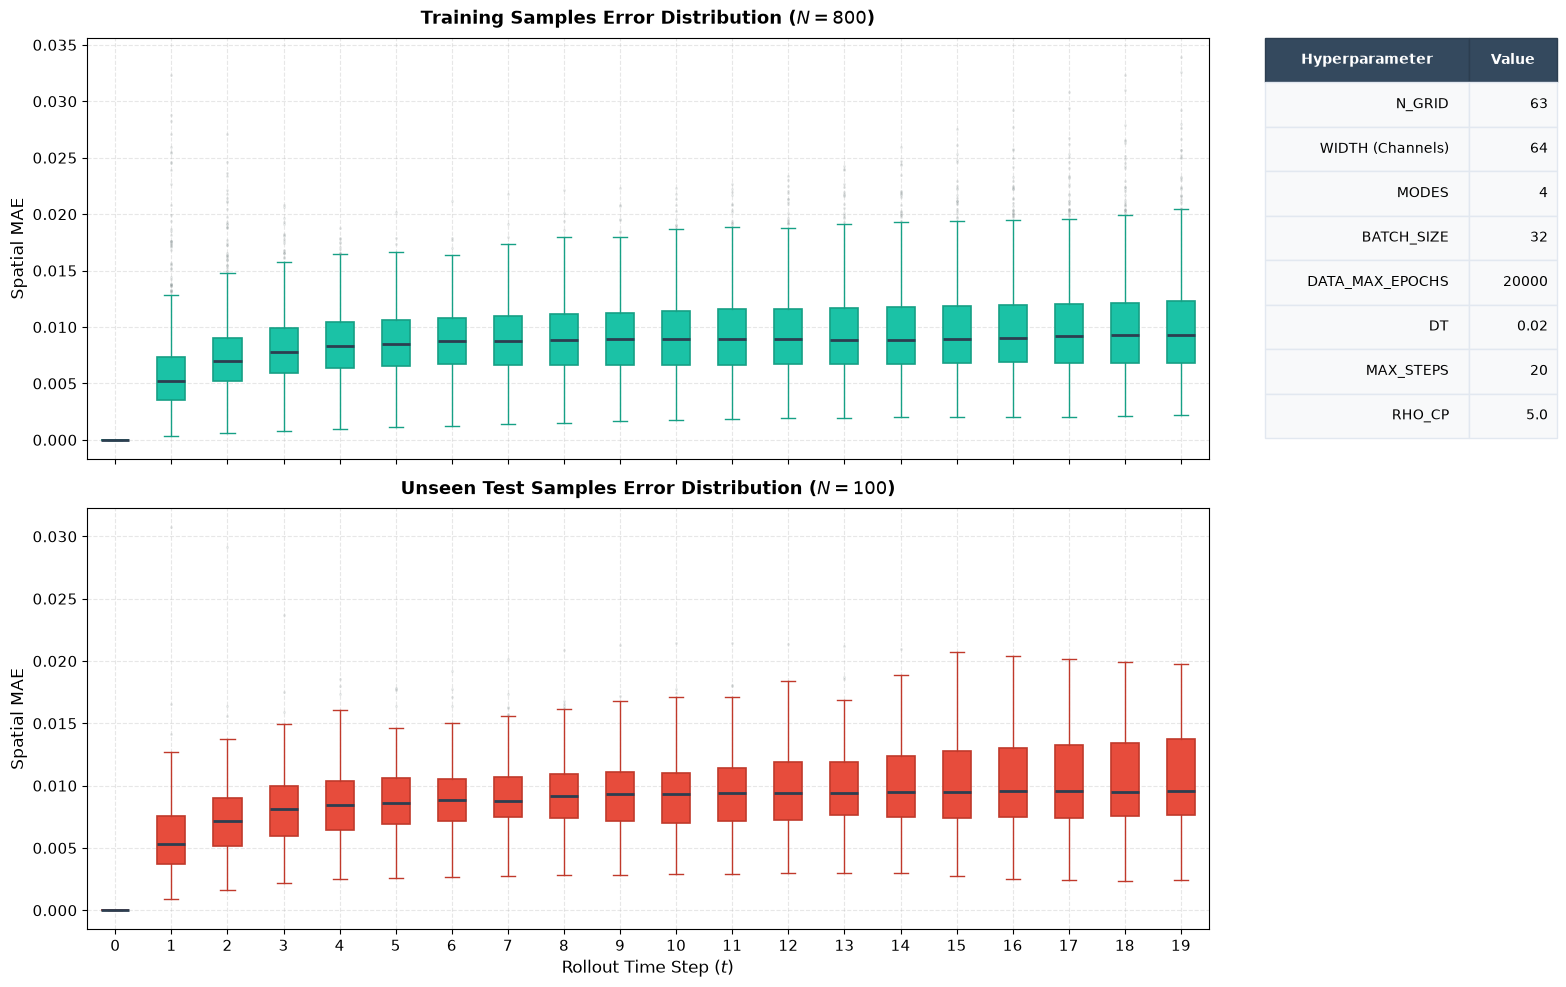

In [6]:
# =====================================================================
# 1. COMPUTE BATCHED ROLLOUT ERRORS (TRAIN vs TEST)
# =====================================================================
print("Computing full rollout errors for all samples...")

@jax.jit(static_argnums=(3,))
def batch_rollout_fno(p, T0_batch, alpha_batch, steps):
    """Performs autoregressive rollout for an entire batch of trajectories."""
    def step(T_curr, _):
        grid_b = jnp.tile(GRID, (T0_batch.shape[0], 1))
        x_raw = jnp.stack([T_curr, alpha_batch, grid_b], axis=-1)
        x_norm = (x_raw - x_mean) / x_std
        T_next = jax.vmap(model.fno_model, (None, 0, 0))(p, x_norm, T_curr)
        return T_next, T_next

    _, traj = jax.lax.scan(step, T0_batch, None, length=steps)
    traj = jnp.transpose(traj, (1, 0, 2))
    return jnp.concatenate([T0_batch[:, None, :], traj], axis=1)

# Ground truth: the shared FEM reference loaded in Section 5. The test partition starts
# at ROLLOUT_TEST_START -- samples TRAIN_SAMPLES:ROLLOUT_TEST_START are the validation
# set early stopping selected the checkpoint with.
true_train = true_traj_all[:TRAIN_SAMPLES]
true_test = true_traj_all[ROLLOUT_TEST_START:]

# Generate FNO predictions
pred_train = batch_rollout_fno(params, all_T0[:TRAIN_SAMPLES], all_Alpha[:TRAIN_SAMPLES], MAX_STEPS-1)
pred_test  = batch_rollout_fno(params, all_T0[ROLLOUT_TEST_START:], all_Alpha[ROLLOUT_TEST_START:], MAX_STEPS-1)

# Calculate Mean Absolute Error across spatial nodes per time step
spatial_mae_train = jnp.mean(jnp.abs(true_train - pred_train), axis=2)
spatial_mae_test  = jnp.mean(jnp.abs(true_test - pred_test), axis=2)


# =====================================================================
# 2. BOX PLOT VISUALIZATION WITH HYPERPARAMETER TABLE
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_error_boxplots(mae_train, mae_test):
    mae_train_np = np.array(mae_train)
    mae_test_np = np.array(mae_test)
    
    n_steps = mae_train_np.shape[1]
    steps = np.arange(n_steps)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    plt.rcParams.update({'font.size': 11})
    
    flier_props = dict(marker='.', markersize=4, markerfacecolor='#7f8c8d', 
                       markeredgecolor='none', alpha=0.2)
    median_props = dict(color='#2c3e50', linewidth=2)

    # --- Panel 1: Training Set Distribution ---
    box_train = dict(facecolor='#1bc2a6', color='#16a085', linewidth=1.2)
    axes[0].boxplot(
        mae_train_np, positions=steps, patch_artist=True,
        boxprops=box_train, whiskerprops=dict(color='#16a085'),
        capprops=dict(color='#16a085'), medianprops=median_props, flierprops=flier_props
    )
    axes[0].set_title(f"Training Samples Error Distribution ($N={TRAIN_SAMPLES}$)", fontweight='bold', fontsize=13, pad=10)
    axes[0].set_ylabel("Spatial MAE", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.3)
    
    # --- Panel 2: Unseen Test Set Distribution ---
    box_test = dict(facecolor='#e74c3c', color='#c0392b', linewidth=1.2)
    axes[1].boxplot(
        mae_test_np, positions=steps, patch_artist=True,
        boxprops=box_test, whiskerprops=dict(color='#c0392b'),
        capprops=dict(color='#c0392b'), medianprops=median_props, flierprops=flier_props
    )
    axes[1].set_title(f"Unseen Test Samples Error Distribution ($N={N_SAMPLES - ROLLOUT_TEST_START}$)", fontweight='bold', fontsize=13, pad=10)
    axes[1].set_xlabel("Rollout Time Step ($t$)", fontsize=12)
    axes[1].set_ylabel("Spatial MAE", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.3)
    
    plt.xticks(steps, labels=[str(s) for s in steps])
    
    # --- 3. HYPERPARAMETER TABLE (FIXED CLIPPING) ---
    hyperparams = [
        ["N_GRID", str(N_GRID)],
        ["WIDTH (Channels)", str(WIDTH)],
        ["MODES", str(MODES)],
        ["BATCH_SIZE", str(BATCH_SIZE)],
        ["DATA_MAX_EPOCHS", str(DATA_MAX_EPOCHS)],
        ["DT", str(DT)],
        ["MAX_STEPS", str(MAX_STEPS)],
        ["RHO_CP", str(RHO_CP)]
    ]
    
    # Adjusted rect to give 23% space on the right for the wider table
    plt.tight_layout(rect=[0, 0, 0.77, 1])
    
    # Added colWidths [70%, 30%] allocation and increased total bbox width to 0.26
    param_table = axes[0].table(
        cellText=hyperparams,
        colLabels=['Hyperparameter', 'Value'],
        loc='upper right',
        colWidths=[0.70, 0.30],
        bbox=[1.05, 0.05, 0.26, 0.95]
    )
    
    param_table.auto_set_font_size(False)
    param_table.set_fontsize(10)
    
    # Clean formatting for headers and data rows
    for (row, col), cell in param_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#34495e')
            cell.set_edgecolor('#2c3e50')
        else:
            cell.set_facecolor('#f8f9fa')
            cell.set_edgecolor('#e2e8f0')

    plt.show()

# Run the updated plotting routine
plot_error_boxplots(spatial_mae_train, spatial_mae_test)

## 7. Qualitative predictions on unseen trajectories

For a few random held-out samples we show the initial condition and material, the full temporal evolution (FEM vs. FNO), and the absolute-error heat-map. Overlapping curves indicate the operator has reproduced the reference dynamics.

Randomly selected test indices: [935 945 999]


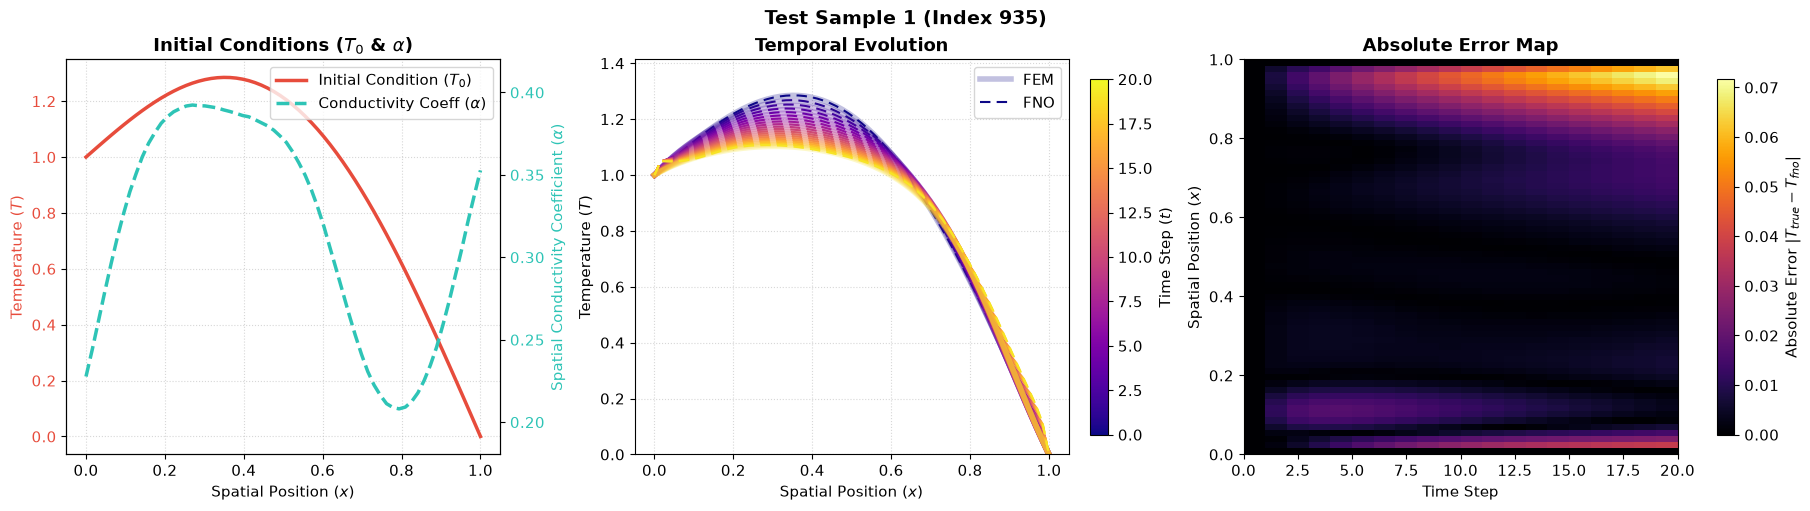

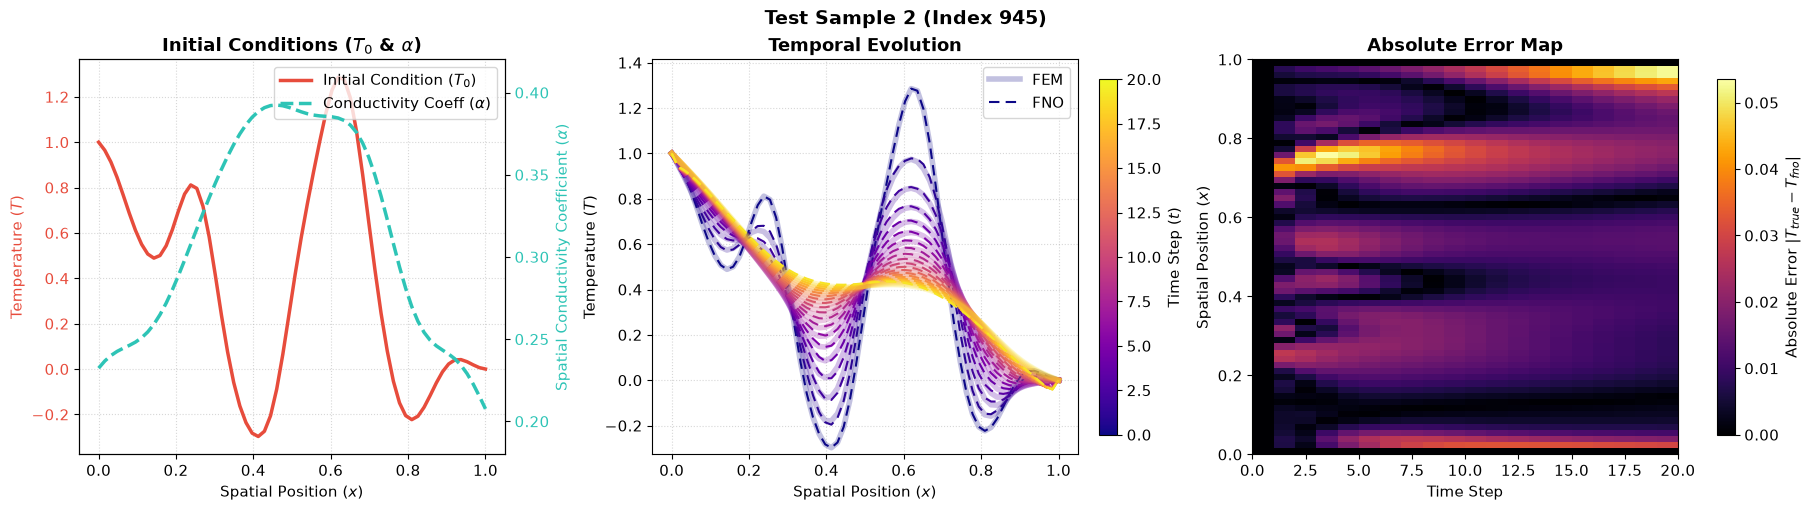

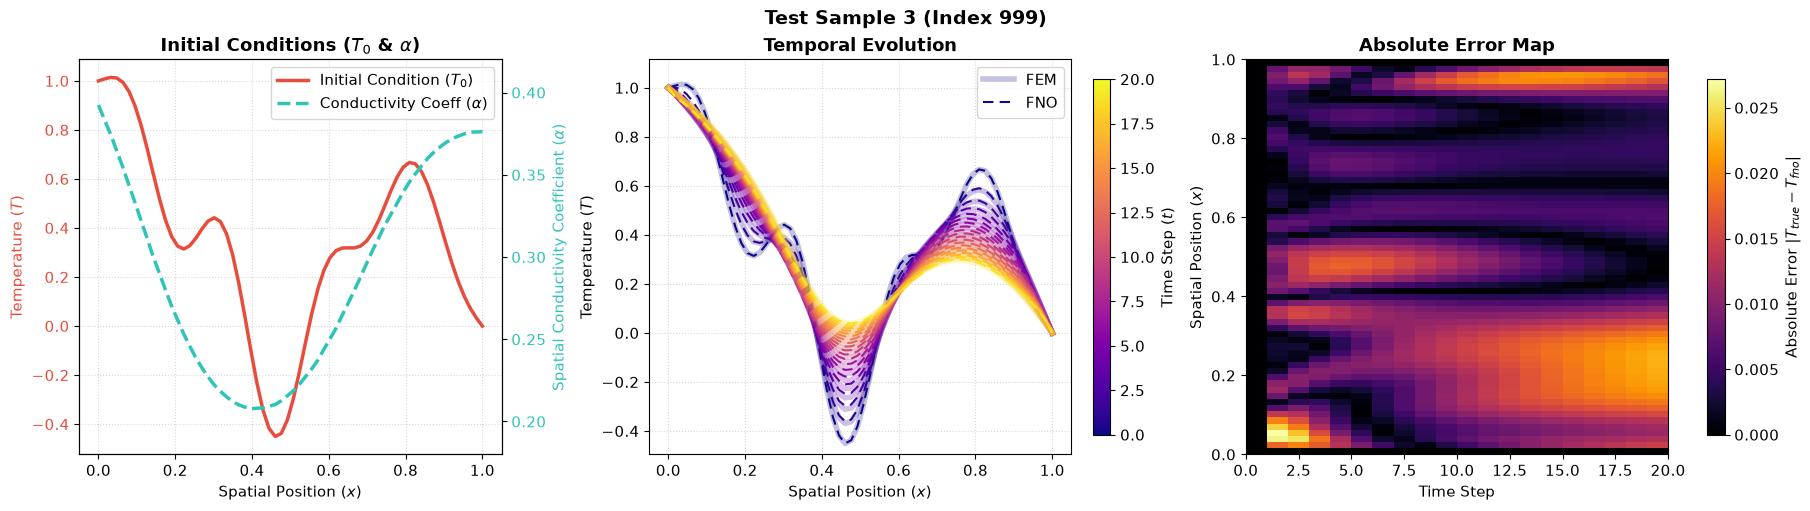

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. RANDOM TEST SELECTION ---
NUM_TEST_SAMPLES = 3  # How many random samples to visualize
test_key = jax.random.PRNGKey(42)  # Change seed for different random samples

# Define the pool (only indices unseen by training AND by early stopping)
test_pool = jnp.arange(ROLLOUT_TEST_START, N_SAMPLES)

# Choose random indices from the test pool
test_indices = jax.random.choice(test_key, test_pool, shape=(NUM_TEST_SAMPLES,), replace=False)

print(f"Randomly selected test indices: {test_indices}")

cmap = plt.get_cmap('plasma')

# --- 2. EVALUATION & VISUALIZATION LOOP ---
for i, test_idx in enumerate(test_indices):
    # Retrieve data for this random index
    T0_test, alpha_test = all_T0[test_idx], all_Alpha[test_idx]
    
    # Generate trajectories (Using local scope functions)
    true_traj = true_traj_all[test_idx]
    fno_pred = rollout_fno(params, T0_test, alpha_test, MAX_STEPS-1)
    fno_traj = jnp.vstack([T0_test, fno_pred])
    error_traj = jnp.abs(true_traj - fno_traj)
    
    # Create Figure: 1 Row, 3 Columns using constrained layout to prevent overlap warnings
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")
    
    # --- COL 1: INITIAL TEMPERATURE & MATERIAL PROFILE (TWIN Y-AXIS) ---
    # Primary axis for Temperature
    line1 = ax1.plot(GRID, T0_test, color='#e74c3c', lw=2.5, label="Initial Condition ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)")
    ax1.set_ylabel("Temperature ($T$)", color='#e74c3c')
    ax1.tick_params(axis='y', labelcolor='#e74c3c')
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Create twin axis for Spatial Conductivity Coefficient (Alpha)
    ax1_twin = ax1.twinx()
    line2 = ax1_twin.plot(GRID, alpha_test, color='#2ec4b6', lw=2.5, ls='--', label="Conductivity Coeff ($\\alpha$)")
    ax1_twin.set_ylabel("Spatial Conductivity Coefficient ($\\alpha$)", color='#2ec4b6')
    ax1_twin.tick_params(axis='y', labelcolor='#2ec4b6')
    
    # Scale secondary axis limits cleanly to fit the dynamic alpha range
    alpha_min, alpha_max = jnp.min(alpha_test), jnp.max(alpha_test)
    alpha_range = abs(alpha_max - alpha_min) if alpha_max != alpha_min else float(alpha_max) * 0.1
    ax1_twin.set_ylim(float(alpha_min) - alpha_range * 0.15, float(alpha_max) + alpha_range * 0.15)
    
    # Combine legends from both axes into one
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")
    
    ax1.set_title("Initial Conditions ($T_0$ & $\\alpha$)", fontweight='bold')
    
    # --- COL 2: TEMPERATURE EVOLUTION (LINE PLOTS) ---
    plot_steps = range(0, MAX_STEPS, 1)  # Plotting every step
    for t in plot_steps:
        color = cmap(t / MAX_STEPS)
        ax2.plot(GRID, true_traj[t], color=color, alpha=0.25, lw=4, label="FEM" if t==0 else "")
        ax2.plot(GRID, fno_traj[t], color=color, ls=(0, (5, 3)), lw=1.5, label="FNO" if t==0 else "")
        
    ax2.set_title("Temporal Evolution", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)")
    ax2.set_ylabel("Temperature ($T$)")
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # Dynamic Y-Limit for Temperature
    y_min, y_max = jnp.min(true_traj), jnp.max(true_traj)
    ax2.set_ylim(y_min - abs(y_min)*0.1, y_max + abs(y_max)*0.1)

    # Dedicated Colorbar for Evolution lines
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    cbar2 = fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9)
    cbar2.set_label('Time Step ($t$)')

    # --- COL 3: ERROR HEATMAP ---
    im3 = ax3.imshow(error_traj.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("Spatial Position ($x$)")
    
    # Dedicated Colorbar for the Heatmap
    cbar3 = fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9)
    cbar3.set_label('Absolute Error $|T_{true} - T_{fno}|$')

    fig.suptitle(f"Test Sample {i+1} (Index {test_idx})", fontsize=14, fontweight='bold')
    plt.show()

## 8. Out-of-distribution stress test: 50 unseen shapes × 6 resolutions

Here the operator faces initial fields from families it was **never** trained on, on grids it was never trained at. The scenarios are exactly the ones the weighted-residual and PITI chapters use:

- **Shape.** 50 fields from four families: *Staircase* (smoothed step), *Pyramid*, *Asymmetric* (two-harmonic mix) and *HF-Rand* (random high-frequency content), split 13 / 13 / 12 / 12, all at constant $\alpha=0.25$.
- **Resolution.** Each shape is evaluated at $N=64$ (training) and at $N=96,128,160,192,256$ (super-resolution).

Ground truth is `fem_ground_truth.py`'s OOD reference: each shape solved once at $N=512$, $\Delta t=0.001$, then interpolated and sub-sampled to each resolution. A few representative examples are shown first, then all evaluations as a box plot and a per-resolution breakdown. This probes whether the operator learned the underlying physics or merely the training distribution.

Evaluating FNO rollout for 50 shapes x 6 resolutions = 300 scenarios...


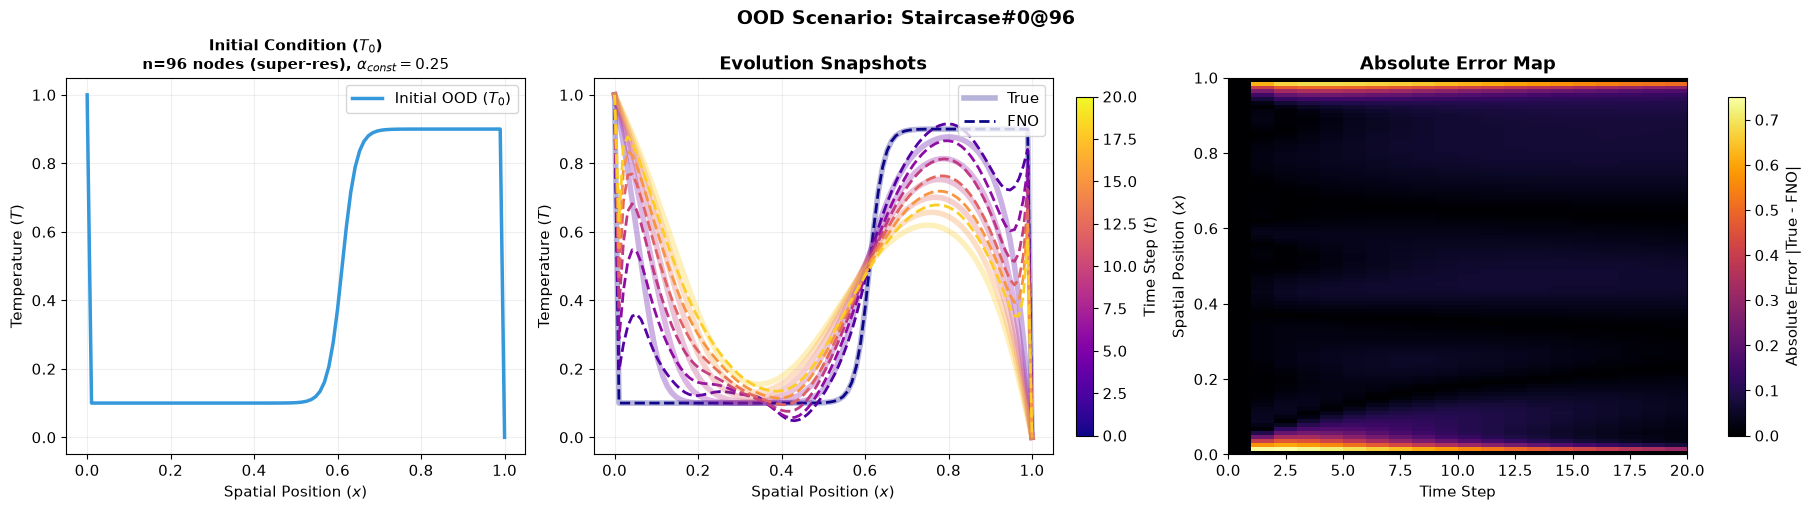

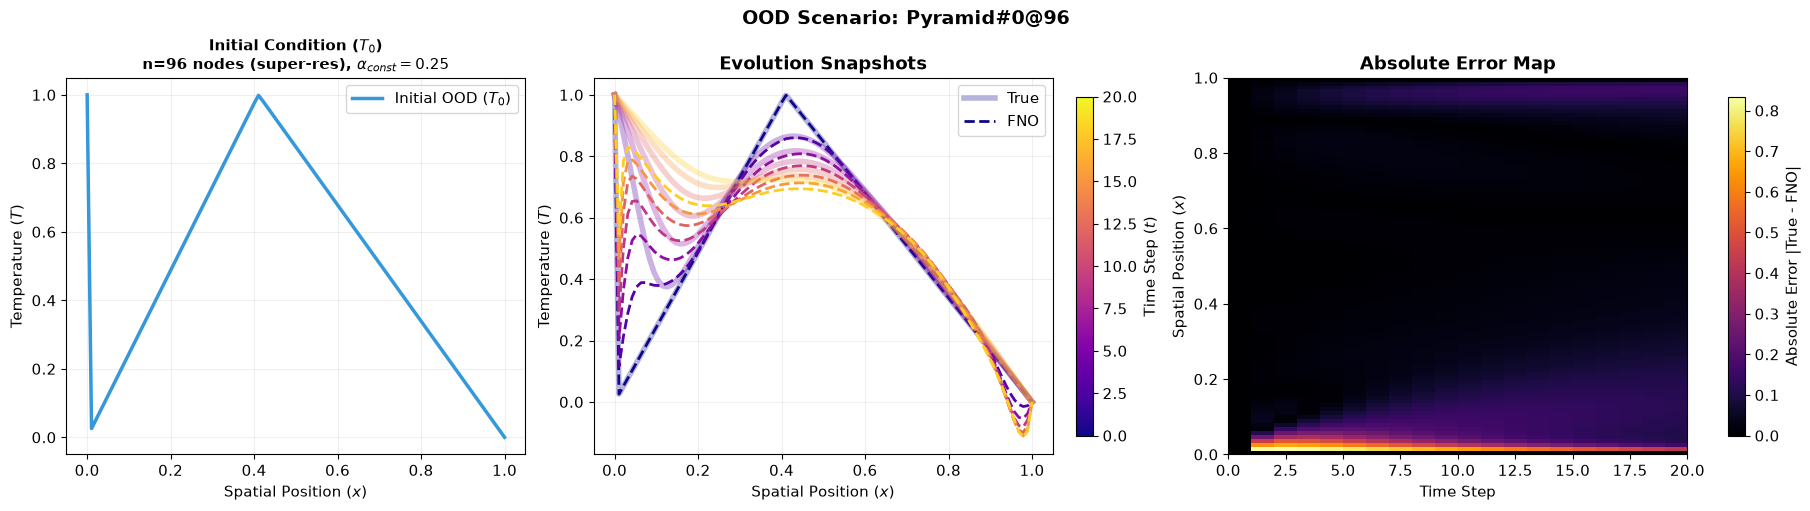

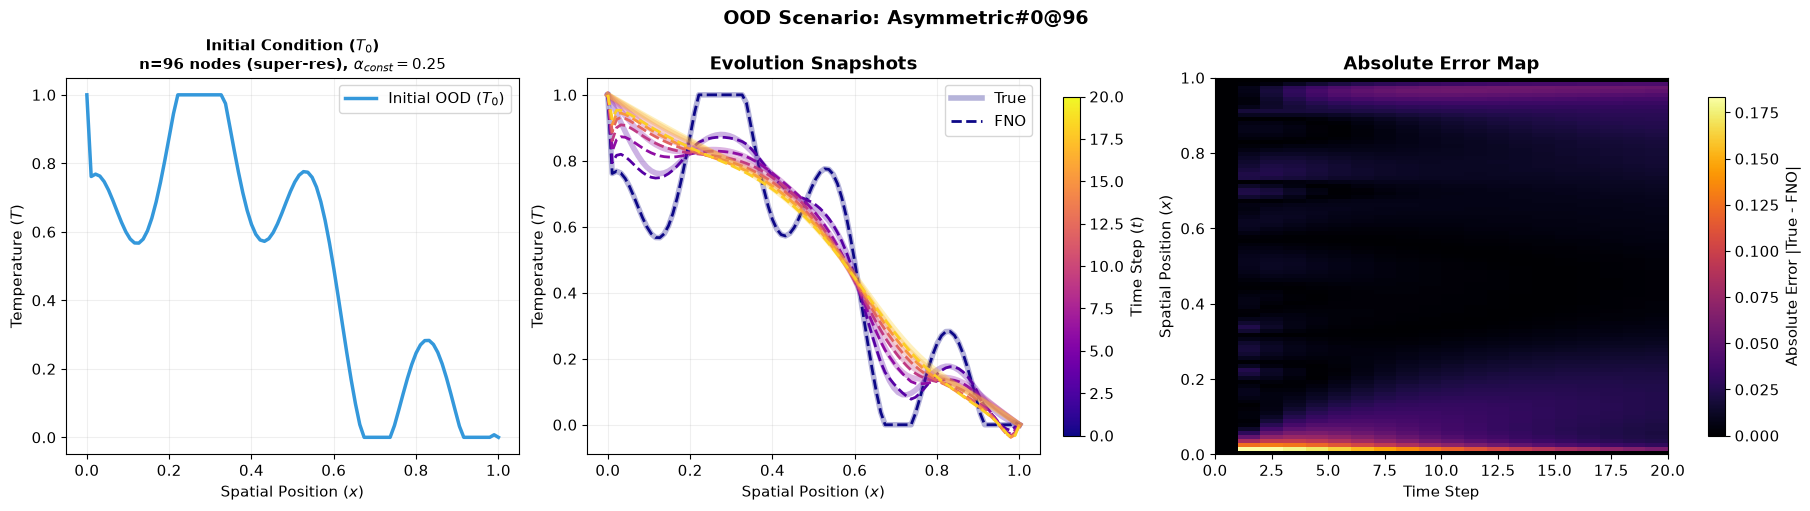

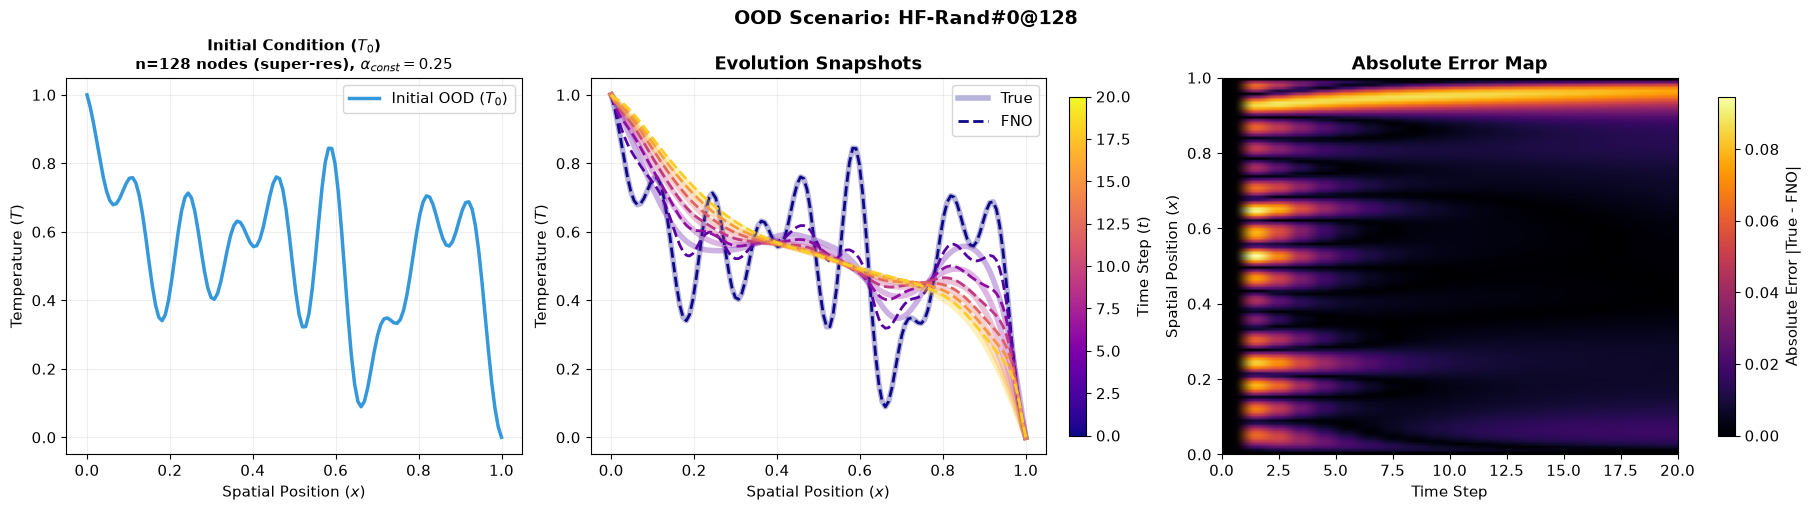

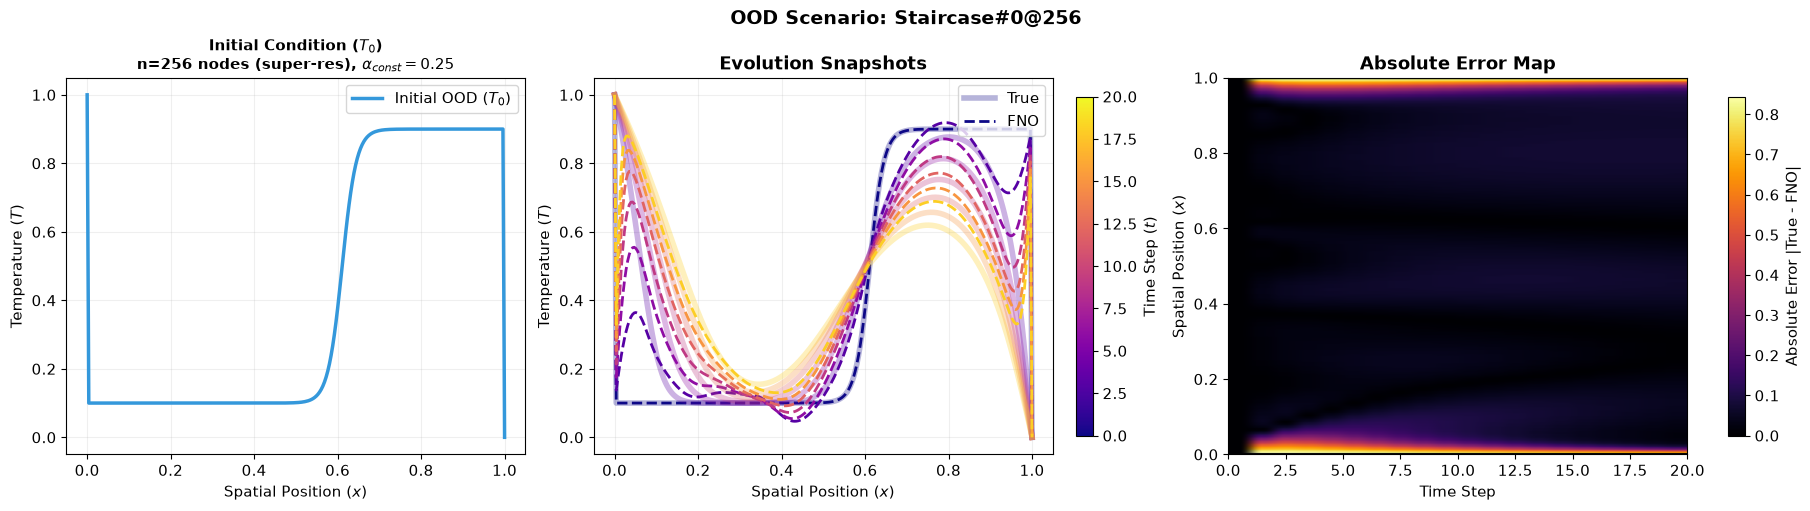

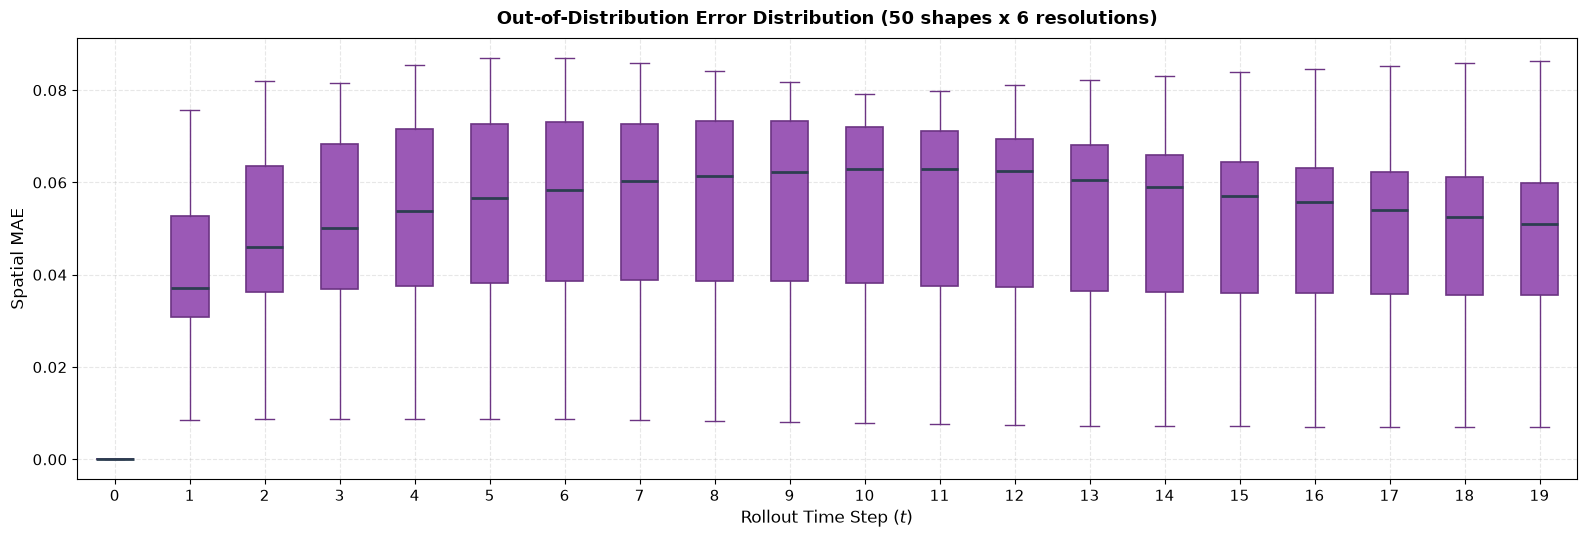


Mean rollout MAE by resolution (averaged over all time steps and shapes):
  N=  64 (training res): mean=4.1341e-02  (n=50)
  N=  96 (super-res): mean=4.6478e-02  (n=50)
  N= 128 (super-res): mean=4.9229e-02  (n=50)
  N= 160 (super-res): mean=5.0940e-02  (n=50)
  N= 192 (super-res): mean=5.2106e-02  (n=50)
  N= 256 (super-res): mean=5.3594e-02  (n=50)


In [8]:
import matplotlib.pyplot as plt
from fem_ground_truth import get_ood_fine_trajectories, derive_ood_dataset

OOD_RES_CHOICES = [N_NODES, 96, 128, 160, 192, 256]
N_OOD = 50
ood_ref = get_ood_fine_trajectories(OOD_REFERENCE_PATH, n_total=N_OOD, dt_ref=REF_DT, steps_ref=REF_STEPS,
                                     reference_n_nodes=512)

def rollout_fno_res(p, T_init, alpha_prof, grid_local, steps):
    """rollout_fno at any resolution. x_mean/x_std are one number per channel,
    so they carry over unchanged to other grids."""
    def step(T_curr, _):
        x_norm = (jnp.stack([T_curr, alpha_prof, grid_local], axis=-1) - x_mean) / x_std
        T_next = model.fno_model(p, x_norm, T_curr)
        return T_next, T_next
    return jax.lax.scan(step, T_init, None, length=steps)[1]

print(f"Evaluating FNO rollout for {N_OOD} shapes x {len(OOD_RES_CHOICES)} resolutions "
      f"= {N_OOD * len(OOD_RES_CHOICES)} scenarios...")
ood_results = []   # (label, family, res, T0, alpha, true_traj, fno_traj)
for res in OOD_RES_CHOICES:
    grid_local = jnp.linspace(0, 1, res)
    for scen in derive_ood_dataset(ood_ref, n_nodes_target=res, dt_target=DT):
        T0_local, alpha_local = jnp.asarray(scen["T0"]), jnp.asarray(scen["alpha"])
        true_traj_local = jnp.asarray(scen["true_traj"])[:MAX_STEPS]
        fno_traj_local = jnp.vstack([T0_local, rollout_fno_res(params, T0_local, alpha_local, grid_local, MAX_STEPS - 1)])
        ood_results.append((scen["label"], scen["family"], res, T0_local, alpha_local, true_traj_local, fno_traj_local))

# --- representative examples: one per family, plus one at the finest grid ---
picks = [next(r for r in ood_results if r[1] == fam and r[2] == 96) for fam in ["Staircase", "Pyramid", "Asymmetric"]]
picks.append(next(r for r in ood_results if r[1] == "HF-Rand" and r[2] == 128))
picks.append(next(r for r in ood_results if r[2] == 256))

cmap = plt.get_cmap('plasma')
for label, fname, res, T0_local, alpha_local, true_traj_local, fno_traj_local in picks:
    grid_local = jnp.linspace(0, 1, res)
    error_map = jnp.abs(true_traj_local - fno_traj_local)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")

    ax1.plot(grid_local, T0_local, color='#3498db', lw=2.5, label="Initial OOD ($T_0$)")
    ax1.set_xlabel("Spatial Position ($x$)"); ax1.set_ylabel("Temperature ($T$)")
    ax1.grid(True, alpha=0.2); ax1.legend(loc="upper right")
    ax1.set_title(f"Initial Condition ($T_0$)\nn={res} nodes ({'training res' if res == N_NODES else 'super-res'}), "
                  f"$\\alpha_{{const}}=0.25$", fontweight='bold', fontsize=11)

    for t in range(0, MAX_STEPS, MAX_STEPS // 6):
        color = cmap(t / MAX_STEPS)
        ax2.plot(grid_local, true_traj_local[t], color=color, alpha=0.3, lw=4, label="True" if t == 0 else "")
        ax2.plot(grid_local, fno_traj_local[t], color=color, ls='--', lw=2, label="FNO" if t == 0 else "")
    ax2.set_title("Evolution Snapshots", fontweight='bold')
    ax2.set_xlabel("Spatial Position ($x$)"); ax2.set_ylabel("Temperature ($T$)")
    ax2.legend(loc="upper right"); ax2.grid(True, alpha=0.2)
    sm2 = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_STEPS))
    fig.colorbar(sm2, ax=ax2, aspect=20, shrink=0.9).set_label('Time Step ($t$)')

    im3 = ax3.imshow(error_map.T, extent=[0, MAX_STEPS, 0, 1], origin='lower', aspect='auto', cmap='inferno')
    ax3.set_title("Absolute Error Map", fontweight='bold')
    ax3.set_xlabel("Time Step"); ax3.set_ylabel("Spatial Position ($x$)")
    fig.colorbar(im3, ax=ax3, aspect=20, shrink=0.9).set_label('Absolute Error |True - FNO|')

    fig.suptitle(f"OOD Scenario: {label}", fontsize=14, fontweight='bold')
    plt.show()

# --- aggregate: box plot over every (shape, resolution) evaluation ---
mae_ood_np = np.stack([np.asarray(jnp.mean(jnp.abs(r[5] - r[6]), axis=1)) for r in ood_results])
steps = np.arange(mae_ood_np.shape[1])
fig, ax = plt.subplots(figsize=(16, 5.5))
ax.boxplot(mae_ood_np, positions=steps, patch_artist=True,
           boxprops=dict(facecolor='#9b59b6', color='#6c3483', linewidth=1.2),
           whiskerprops=dict(color='#6c3483'), capprops=dict(color='#6c3483'),
           medianprops=dict(color='#2c3e50', linewidth=2),
           flierprops=dict(marker='.', markersize=4, markerfacecolor='#7f8c8d', markeredgecolor='none', alpha=0.2))
ax.set_title(f"Out-of-Distribution Error Distribution ({N_OOD} shapes x {len(OOD_RES_CHOICES)} resolutions)",
             fontweight='bold', fontsize=13, pad=10)
ax.set_xlabel("Rollout Time Step ($t$)", fontsize=12); ax.set_ylabel("Spatial MAE", fontsize=12)
ax.set_xticks(steps); ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()

print("\nMean rollout MAE by resolution (averaged over all time steps and shapes):")
for res in OOD_RES_CHOICES:
    vals = [m.mean() for r, m in zip(ood_results, mae_ood_np) if r[2] == res]
    print(f"  N={res:4d} ({'training res' if res == N_NODES else 'super-res'}): mean={np.mean(vals):.4e}  (n={len(vals)})")

## 9. Does out-of-distribution accuracy survive long training?

In-distribution validation above (Section 5) is used to pick the best checkpoint, but it keeps
improving smoothly for as long as we let it train -- it never plateaus or gets worse on its own. To
check whether that also holds out-of-distribution, we retrain from scratch with periodic parameter
snapshots and re-evaluate each snapshot against the 50 OOD shapes of Section 8, at training resolution. If validation keeps
falling while OOD error climbs, training duration itself would be trading away generalization -- a
failure in-distribution monitoring alone cannot see, and a reason to cap the epoch budget below what
validation allows.

epoch      0  OOD final-step mean abs error: 2.178e-01
epoch   1000  OOD final-step mean abs error: 1.458e-01
epoch   2000  OOD final-step mean abs error: 1.340e-01
epoch   3000  OOD final-step mean abs error: 1.072e-01
epoch   4000  OOD final-step mean abs error: 1.056e-01
epoch   5000  OOD final-step mean abs error: 8.808e-02
epoch   6000  OOD final-step mean abs error: 6.739e-02
epoch   7000  OOD final-step mean abs error: 8.543e-02
epoch   8000  OOD final-step mean abs error: 7.041e-02
epoch   9000  OOD final-step mean abs error: 8.366e-02
epoch  10000  OOD final-step mean abs error: 7.109e-02
epoch  11000  OOD final-step mean abs error: 6.124e-02
epoch  12000  OOD final-step mean abs error: 5.657e-02
epoch  13000  OOD final-step mean abs error: 5.098e-02
epoch  14000  OOD final-step mean abs error: 4.441e-02
epoch  15000  OOD final-step mean abs error: 4.392e-02
epoch  16000  OOD final-step mean abs error: 4.065e-02
epoch  17000  OOD final-step mean abs error: 3.902e-02
epoch  180

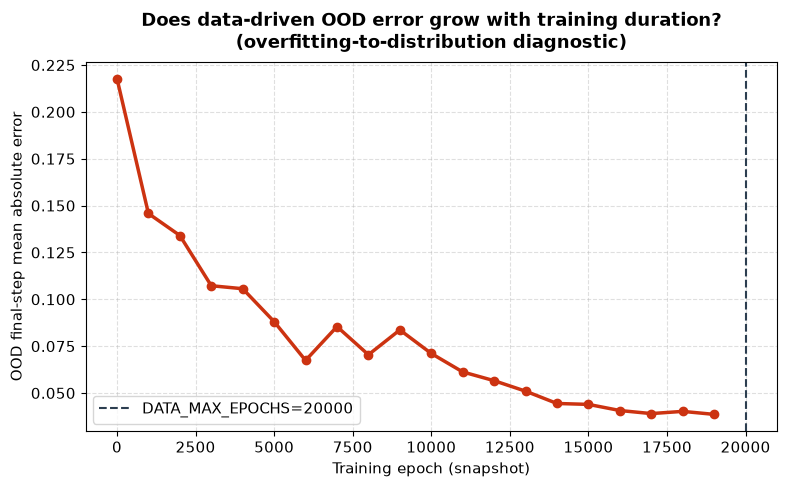

In [9]:
# ============================================================
# Reuses `snapshots` already collected during Section 5's single
# training run (every 1000 epochs, up to MAX_EPOCHS) -- no
# retraining here. Graded on the 50 OOD shapes of Section 8 at
# training resolution, against the same FEM OOD reference.
# ============================================================
_ood64 = derive_ood_dataset(ood_ref, n_nodes_target=N_NODES, dt_target=DT)
ood_T0 = jnp.stack([jnp.asarray(s["T0"]) for s in _ood64])
ood_A = jnp.stack([jnp.asarray(s["alpha"]) for s in _ood64])
ood_true = jnp.stack([jnp.asarray(s["true_traj"])[:MAX_STEPS] for s in _ood64])

def ood_final_error(p):
    pred = batch_rollout_fno(p, ood_T0, ood_A, MAX_STEPS-1)
    return float(jnp.mean(jnp.abs(ood_true - pred)[:, -1]))

diag_epochs = [ep for ep, _ in snapshots]
diag_ood_err = [ood_final_error(p) for _, p in snapshots]
for ep, err in zip(diag_epochs, diag_ood_err):
    print(f"epoch {ep:6d}  OOD final-step mean abs error: {err:.3e}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(diag_epochs, diag_ood_err, marker='o', color='#CC3311', lw=2.5)
ax.axvline(DATA_MAX_EPOCHS, color='#2c3e50', ls='--', lw=1.5, label=f"DATA_MAX_EPOCHS={DATA_MAX_EPOCHS}")
ax.set_xlabel("Training epoch (snapshot)")
ax.set_ylabel("OOD final-step mean absolute error")
ax.set_title("Does data-driven OOD error grow with training duration?\n(overfitting-to-distribution diagnostic)", fontweight='bold', pad=10)
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

**Finding.** No such trade-off appears. Out-of-distribution error falls almost monotonically over the whole run, with a few noisy early snapshots, and ends at its lowest value. In-distribution validation and OOD accuracy improve together, so selecting the checkpoint by in-distribution validation over the full budget is safe here. The model used throughout this chapter is therefore the best-validation checkpoint of the full 20000-epoch run, with the same budget as the weighted-residual and PITI chapters, and no separate cap.

An earlier version of this chapter did observe OOD error rising under long training. That version generated its own data (a different initial-field sampler, $N=65$, `MODES=8`) and graded it against coarse per-resolution FEM solves. On the shared fine FEM reference used by every transient chapter now, the effect does not reproduce. The out-of-distribution gap to the physics-trained operators is examined directly in the comparison chapter.

## 10. Discussion

- **In distribution**, the supervised operator tracks the FEM reference closely over the whole rollout. Its error grows slowly with the number of steps, as small per-step errors are fed back as inputs. The first step is close to the discretization floor of the $N=64$, $\Delta t=0.02$ grid ([The Benchmark Problem](benchmark_problem.ipynb), Section 7), and later steps stay within a small multiple of it.
- **Out of distribution**, the error is several times larger than in distribution. It grows moderately with the grid resolution, since finer grids carry detail the network never saw.
- **Training duration** (Section 9) does not trade away generalization on this benchmark. In-distribution validation and out-of-distribution error improve together, so the full early-stopped budget is used.

This operator needs FEM trajectories for training, i.e. many expensive solver runs. The next chapter, [Physics-Informed Operator Learning with a Finite-Element Weak Form](FNO_transient_weighted_residual.ipynb), removes the labels entirely and trains the same network on the finite-element residual, from initial states only.